In [1]:
import numpy as np
import ode_solver as solver
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd

In [2]:
pd.set_option('display.precision', 15)

In [ ]:
def Thomas_Fermi(x,z):
    return np.array([z[1],np.power(z[0],1.5)/np.sqrt(x)])

In [ ]:
x0=np.power(10.0,-235)
v_=-1.5880710226113753127186845094239501093
T_list=[4,5,15,100,500]
solver_methods=['RK62','RK43','Trap']
df=pd.DataFrame(columns=['method','last node','value at the end','steps'])

In [ ]:
for T in T_list:
    TF=solver.ode_solver(Thomas_Fermi,[1,v_],[0,T],method=solver_methods[0],rtol=np.power(10,-13.5))
    TF.solve()
    df.loc[len(df)]=[solver_methods[0],TF.time[-1],TF.sol[-1][0],np.shape(TF.time)[0]]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24092\177522021.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.array([z[1],np.power(z[0],1.5)/np.sqrt(x)])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24092\177522021.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.array([z[1],np.power(z[0],1.5)/np.sqrt(x)])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24092\177522021.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.array([z[1],np.power(z[0],1.5)/np.sqrt(x)])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24092\177522021.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.array([z[1],np.power(z[0],1.5)/np.sqrt(x)])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24092\177522021.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.array([z[1],np.power(z[0],1.5)/np.sqrt(x)])


In [ ]:
method=['Radau','RK45','RK23','DOP853','LSODA']
for metoda in method:
    for X in T_list:
        TF=solve_ivp(Thomas_Fermi,[x0,X],[1,v_],method=metoda,rtol=2.220446049250313e-14,atol=2.220446049250313e-14)
        df.loc[len(df)]=[metoda,TF.t[-1],TF.y[0,-1],np.shape(TF.t)[0]]

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24092\177522021.py:2: RuntimeWarning: invalid value encountered in power
  return np.array([z[1],np.power(z[0],1.5)/np.sqrt(x)])


In [39]:
df

,method,last node,value at the end,steps
0,RK62,4.000000000000000,1.084042569193013e-01,149772
1,RK62,5.000000000000000,7.880777925204645e-02,154362
2,RK62,15.000000000000000,1.080535877386399e-02,173098
3,RK62,100.000000000000000,1.002764129579450e-04,188070
4,RK62,500.000000000000000,1.344496201104467e-04,192941
5,Radau,4.000000000000000,1.084042569186719e-01,7874
6,Radau,5.000000000000000,7.880777925096689e-02,8115
7,Radau,15.000000000000000,1.080535874508629e-02,9168
8,Radau,100.000000000000000,1.002224225003943e-04,10241
9,Radau,321.641618878859504,3.793672249628211e-20,10526


In [ ]:
End=df[len(T_list)-1:len(df):len(T_list)]
End

,method,last node,value at the end,steps
4,RK62,500.000000000000000,1.344496201104467e-04,192941
9,Radau,321.641618878859504,3.793672249628211e-20,10526
14,RK45,333.795969373626860,6.702559698944907e+42,20339
19,RK23,411.620499055685400,1.808520390326839e+35,1323063
24,DOP853,456.142208167189892,2.173337314548002e+47,2101
29,LSODA,500.000000000000000,5.532937703213914e-02,2190


In [17]:
def _oregonator(t,z):
    u,v,w=z
    epsilon=0.1
    q=0.0008
    delta=0.0004
    f=1
    a=1
    b=1
    return [(a*u+q*a*v-u**2-u*v)/epsilon,(-q*a*v+f*b*w-u*v)/delta,a*u-b*w]

In [18]:
O=solver.ode_solver(_oregonator,[0,124,0.16],[0,30],'RK62',rtol=1e-11)

In [19]:
O.solve()

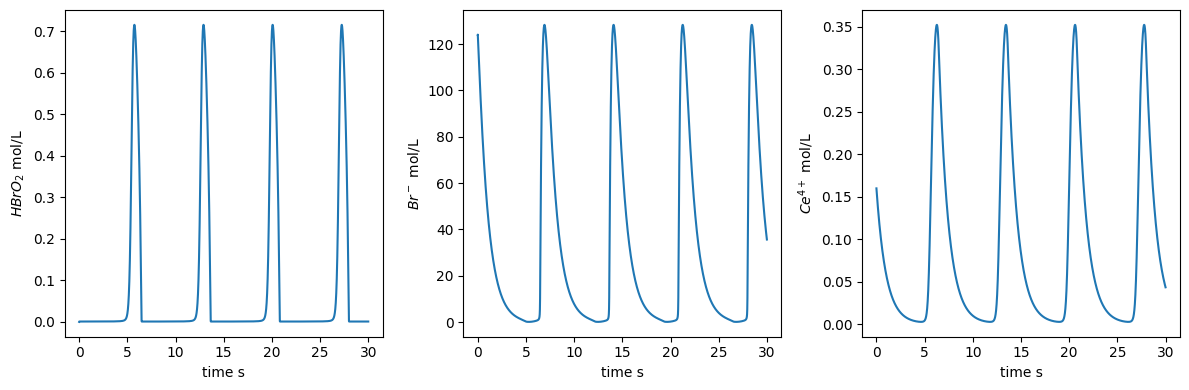

In [21]:
names=['$HBrO_2$','$Br^-$','$Ce^{4+}$']
fig,ax=plt.subplots(1,3,figsize=(12,4))
for i,name in zip(range(3),names):
    ax[i].plot(O.time,O.sol[:,i])
    ax[i].set_ylabel(f'{name} mol/L')
    ax[i].set_xlabel("time s")
plt.tight_layout()
plt.show()